In [ ]:
# @title 🔗 CELLULE 1 - Monter Google Drive et vérifier le dataset
from google.colab import drive
import os

# Monter le Drive
drive.mount('/content/drive')

# Vérifier le chemin du dataset
data_path = '/content/drive/MyDrive/Data/'
json_file = os.path.join(data_path, 'VQA_RAD Dataset Public.json')
image_folder = os.path.join(data_path, 'VQA_RAD Image Folder')

print("="*60)
print("VÉRIFICATION DU DATASET")
print("="*60)
print(f"JSON existe : {os.path.exists(json_file)}")
print(f"Dossier images existe : {os.path.exists(image_folder)}")

if os.path.exists(image_folder):
    images = [f for f in os.listdir(image_folder) if f.endswith('.jpg')]
    print(f"Nombre d'images : {len(images)}")

print("\n✅ Cellule 1 exécutée avec succès !")

Mounted at /content/drive
VÉRIFICATION DU DATASET
JSON existe : True
Dossier images existe : True
Nombre d'images : 315

✅ Cellule 1 exécutée avec succès !


In [ ]:
# @title 📦 CELLULE 2 - Installation des bibliothèques pour ViLBERT
print("="*60)
print("INSTALLATION DES BIBLIOTHÈQUES")
print("="*60)

# Installer les packages nécessaires
!pip install torch torchvision --quiet
!pip install transformers datasets tokenizers timm --quiet
!pip install scikit-learn tqdm matplotlib --quiet
!pip install pillow opencv-python-headless --quiet

print("\n✅ Toutes les bibliothèques sont installées !")
print("   - PyTorch + torchvision")
print("   - Transformers (HuggingFace)")
print("   - timm (ViT models)")
print("   - scikit-learn, tqdm, matplotlib")

INSTALLATION DES BIBLIOTHÈQUES

✅ Toutes les bibliothèques sont installées !
   - PyTorch + torchvision
   - Transformers (HuggingFace)
   - timm (ViT models)
   - scikit-learn, tqdm, matplotlib


In [ ]:
# @title 📚 CELLULE 3 - Imports des bibliothèques
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
import json
import os
from collections import Counter
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Vérifier GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("="*60)
print("IMPORTS RÉUSSIS")
print("="*60)
print(f"✅ Device : {device}")
if torch.cuda.is_available():
    print(f"   GPU : {torch.cuda.get_device_name(0)}")
print(f"✅ PyTorch version : {torch.__version__}")
print(f"✅ Toutes les bibliothèques sont importées")

IMPORTS RÉUSSIS
✅ Device : cuda
   GPU : Tesla T4
✅ PyTorch version : 2.10.0+cu128
✅ Toutes les bibliothèques sont importées


In [ ]:
# @title 📊 CELLULE 4 - Chargement et exploration du dataset
import json

# Chemins
json_file = '/content/drive/MyDrive/Data/VQA_RAD Dataset Public.json'
image_folder = '/content/drive/MyDrive/Data/VQA_RAD Image Folder'

# Charger le JSON
with open(json_file, 'r') as f:
    samples = json.load(f)

print("="*60)
print("CHARGEMENT DU DATASET VQA-RAD")
print("="*60)
print(f"✅ Nombre total d'échantillons : {len(samples)}")
print(f"✅ Type des données : {type(samples)}")

# Afficher les 10 premières questions
print("\n📖 PREMIÈRES QUESTIONS :")
print("-"*40)
for i in range(min(5, len(samples))):
    print(f"{i+1}. {samples[i]['question'][:60]}... → {samples[i]['answer']}")

# Compter les types de réponses
closed_count = sum(1 for s in samples if s['answer_type'] == 'CLOSED')
open_count = len(samples) - closed_count

print(f"\n📊 STATISTIQUES :")
print(f"   Questions CLOSED : {closed_count} ({closed_count/len(samples)*100:.1f}%)")
print(f"   Questions OPEN   : {open_count} ({open_count/len(samples)*100:.1f}%)")

# Compter les images uniques
unique_images = len(set(s['image_name'] for s in samples))
print(f"   Images uniques    : {unique_images}")

print("\n✅ Dataset chargé avec succès !")

CHARGEMENT DU DATASET VQA-RAD
✅ Nombre total d'échantillons : 2248
✅ Type des données : <class 'list'>

📖 PREMIÈRES QUESTIONS :
----------------------------------------
1. Are regions of the brain infarcted?... → Yes
2. Are the lungs normal appearing?... → No
3. Is there evidence of a pneumothorax... → No
4. What type of imaging does this not represent?... → ultrasound
5. Is this a MRI of the chest?... → no

📊 STATISTIQUES :
   Questions CLOSED : 1297 (57.7%)
   Questions OPEN   : 951 (42.3%)
   Images uniques    : 314

✅ Dataset chargé avec succès !


In [ ]:
# @title 🔧 CELLULE 5 - Dataset PyTorch personnalisé pour VQA-RAD (Version corrigée)

class VQARADDataset(Dataset):
    def __init__(self, samples, image_folder, transform=None):
        # Filtrer pour ne garder que les dictionnaires
        self.samples = [s for s in samples if isinstance(s, dict)]
        self.image_folder = image_folder
        self.transform = transform

        print(f"📊 Filtrage : {len(self.samples)} dictionnaires sur {len(samples)} éléments")

        # Construire le vocabulaire des réponses
        self.build_vocabulary()

    def build_vocabulary(self):
        # Réponses fermées (CLOSED)
        closed_answers = []
        for s in self.samples:
            if 'answer_type' in s and s['answer_type'] == 'CLOSED':
                if 'answer' in s:
                    closed_answers.append(str(s['answer']).lower().strip())

        closed_counts = Counter(closed_answers)
        top_closed = [ans for ans, _ in closed_counts.most_common(500)]
        self.closed_answer_to_idx = {ans: idx for idx, ans in enumerate(top_closed)}
        self.idx_to_closed_answer = {idx: ans for ans, idx in self.closed_answer_to_idx.items()}

        # Réponses ouvertes (OPEN)
        open_answers = []
        for s in self.samples:
            if 'answer_type' in s and s['answer_type'] == 'OPEN':
                if 'answer' in s:
                    open_answers.append(str(s['answer']).lower().strip())

        open_answers = list(set(open_answers))
        self.open_answer_to_idx = {ans: idx for idx, ans in enumerate(open_answers)}
        self.idx_to_open_answer = {idx: ans for ans, idx in self.open_answer_to_idx.items()}

        print(f"✅ Vocabulaire construit :")
        print(f"   - Réponses fermées : {len(self.closed_answer_to_idx)} classes")
        print(f"   - Réponses ouvertes : {len(self.open_answer_to_idx)} classes")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # Charger l'image
        img_name = sample.get('image_name', '')
        img_path = os.path.join(self.image_folder, img_name)

        try:
            if os.path.exists(img_path):
                image = Image.open(img_path).convert('RGB')
            else:
                image = Image.new('RGB', (224, 224), color='gray')
        except:
            image = Image.new('RGB', (224, 224), color='gray')

        if self.transform:
            image = self.transform(image)

        # Récupérer question et réponse
        question = sample.get('question', '')
        answer = str(sample.get('answer', '')).lower().strip()
        answer_type = sample.get('answer_type', 'CLOSED')

        # Convertir en index
        if answer_type == 'CLOSED':
            answer_idx = self.closed_answer_to_idx.get(answer, 0)
            open_answer_idx = -1
        else:
            answer_idx = -1
            open_answer_idx = self.open_answer_to_idx.get(answer, 0)

        return {
            'image': image,
            'question': question,
            'answer': answer,
            'answer_type': answer_type,
            'answer_idx': answer_idx,
            'open_answer_idx': open_answer_idx,
            'image_name': img_name
        }

# Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Créer le dataset
full_dataset = VQARADDataset(samples, image_folder, transform=transform)

print("\n✅ Dataset PyTorch créé avec succès !")
print(f"   Taille totale : {len(full_dataset)} échantillons")

📊 Filtrage : 2248 dictionnaires sur 2248 éléments
✅ Vocabulaire construit :
   - Réponses fermées : 64 classes
   - Réponses ouvertes : 483 classes

✅ Dataset PyTorch créé avec succès !
   Taille totale : 2248 échantillons


In [ ]:
# @title ✂️ CELLULE 6 - Division Train / Validation / Test
from sklearn.model_selection import train_test_split

print("="*60)
print("DIVISION DES DONNÉES")
print("="*60)

# Indices
indices = list(range(len(full_dataset)))

# Récupérer les types pour information
answer_types = [full_dataset[i]['answer_type'] for i in indices]
closed_count = answer_types.count('CLOSED')
open_count = len(indices) - closed_count

print(f"📊 Distribution originale :")
print(f"   CLOSED : {closed_count} ({closed_count/len(indices)*100:.1f}%)")
print(f"   OPEN   : {open_count} ({open_count/len(indices)*100:.1f}%)")

# 1er split : train (70%) vs temp (30%)
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.3,
    random_state=42
)

# 2ème split : val (50% de temp = 15%) vs test (50% de temp = 15%)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=42
)

# Créer les sous-datasets
train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_idx)
test_dataset = Subset(full_dataset, test_idx)

print(f"\n📊 STATISTIQUES DE DIVISION :")
print(f"   Train       : {len(train_idx)} samples ({len(train_idx)/len(indices)*100:.1f}%)")
print(f"   Validation  : {len(val_idx)} samples ({len(val_idx)/len(indices)*100:.1f}%)")
print(f"   Test        : {len(test_idx)} samples ({len(test_idx)/len(indices)*100:.1f}%)")

print("\n✅ Division terminée avec succès !")

DIVISION DES DONNÉES
📊 Distribution originale :
   CLOSED : 1297 (57.7%)
   OPEN   : 951 (42.3%)

📊 STATISTIQUES DE DIVISION :
   Train       : 1573 samples (70.0%)
   Validation  : 337 samples (15.0%)
   Test        : 338 samples (15.0%)

✅ Division terminée avec succès !


In [ ]:
# @title 🚂 CELLULE 7 - Création des DataLoaders
from torch.utils.data import DataLoader

# Batch size adapté pour ViLBERT (plus gourmand en mémoire)
batch_size = 16

# Créer les DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print("="*60)
print("DATALOADERS CRÉÉS")
print("="*60)
print(f"✅ Batch size : {batch_size}")
print(f"✅ Train loader   : {len(train_loader)} batches")
print(f"✅ Validation loader : {len(val_loader)} batches")
print(f"✅ Test loader    : {len(test_loader)} batches")

# Tester un batch
print("\n🔍 Test d'un batch :")
batch = next(iter(train_loader))
print(f"   Images shape : {batch['image'].shape}")
print(f"   Questions    : {len(batch['question'])}")
print(f"   Answer types : {batch['answer_type'][:5]}")
print(f"   Answer idx   : {batch['answer_idx'][:5]}")

print("\n✅ DataLoaders prêts pour l'entraînement !")

DATALOADERS CRÉÉS
✅ Batch size : 16
✅ Train loader   : 99 batches
✅ Validation loader : 22 batches
✅ Test loader    : 22 batches

🔍 Test d'un batch :
   Images shape : torch.Size([16, 3, 224, 224])
   Questions    : 16
   Answer types : ['OPEN', 'OPEN', 'OPEN', 'OPEN', 'CLOSED']
   Answer idx   : tensor([-1, -1, -1, -1,  0])

✅ DataLoaders prêts pour l'entraînement !


In [ ]:
# @title 🧠 CELLULE 8 - Import des modèles ViT et BERT
from transformers import BertTokenizer, BertModel
import timm

print("="*60)
print("CHARGEMENT DES MODÈLES PRÉ-ENTRAÎNÉS")
print("="*60)

# Tokenizer BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Encodeur texte : BERT
text_encoder = BertModel.from_pretrained('bert-base-uncased')
text_encoder = text_encoder.to(device)

# Encodeur image : ViT-B/16
image_encoder = timm.create_model('vit_base_patch16_224', pretrained=True)
image_encoder.head = nn.Identity()  # Enlever la tête de classification
image_encoder = image_encoder.to(device)

print("✅ Modèles chargés avec succès !")
print(f"   - ViT-B/16  : {sum(p.numel() for p in image_encoder.parameters()):,} paramètres")
print(f"   - BERT-base : {sum(p.numel() for p in text_encoder.parameters()):,} paramètres")
print(f"   - Device    : {device}")

# Geler les encodeurs au début (fine-tuning progressif)
for param in image_encoder.parameters():
    param.requires_grad = False
for param in text_encoder.parameters():
    param.requires_grad = False

print("\n⚠️ Encodeurs gelés (fine-tuning progressif plus tard)")

CHARGEMENT DES MODÈLES PRÉ-ENTRAÎNÉS


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

✅ Modèles chargés avec succès !
   - ViT-B/16  : 85,798,656 paramètres
   - BERT-base : 109,482,240 paramètres
   - Device    : cuda

⚠️ Encodeurs gelés (fine-tuning progressif plus tard)


In [ ]:
# @title 🏗️ CELLULE 9 - Modèle ViLBERT avec Co-attention

class ViLBERTModel(nn.Module):
    def __init__(self, image_encoder, text_encoder, num_closed, num_open, hidden_size=768, num_heads=8):
        super().__init__()

        # Encodeurs
        self.image_encoder = image_encoder
        self.text_encoder = text_encoder

        # Projections pour aligner les dimensions
        self.image_proj = nn.Linear(768, hidden_size)
        self.text_proj = nn.Linear(768, hidden_size)

        # Co-attention : image attend texte et texte attend image
        self.cross_attn_image_to_text = nn.MultiheadAttention(hidden_size, num_heads, batch_first=True)
        self.cross_attn_text_to_image = nn.MultiheadAttention(hidden_size, num_heads, batch_first=True)

        # Layer Normalization
        self.norm_image = nn.LayerNorm(hidden_size)
        self.norm_text = nn.LayerNorm(hidden_size)

        # Fusion
        self.fusion = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # Têtes de réponse
        self.closed_head = nn.Linear(hidden_size // 2, num_closed)
        self.open_head = nn.Linear(hidden_size // 2, num_open)

    def forward(self, image, input_ids, attention_mask):
        # 1. Encoder l'image avec ViT
        image_features = self.image_encoder(image)
        image_features = self.image_proj(image_features).unsqueeze(1)  # [batch, 1, hidden]

        # 2. Encoder le texte avec BERT
        text_outputs = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_features = self.text_proj(text_outputs.last_hidden_state)  # [batch, seq_len, hidden]

        # 3. Co-attention bidirectionnelle
        # Image → attend Texte
        attn_out_image, _ = self.cross_attn_image_to_text(
            query=image_features,
            key=text_features,
            value=text_features
        )
        image_features = self.norm_image(image_features + attn_out_image)

        # Texte → attend Image
        attn_out_text, _ = self.cross_attn_text_to_image(
            query=text_features,
            key=image_features,
            value=image_features
        )
        text_features = self.norm_text(text_features + attn_out_text)

        # 4. Pooling : moyenne sur les tokens texte
        text_pooled = text_features.mean(dim=1)  # [batch, hidden]
        image_pooled = image_features.squeeze(1)  # [batch, hidden]

        # 5. Fusion
        combined = torch.cat([image_pooled, text_pooled], dim=1)
        fused = self.fusion(combined)

        # 6. Sorties
        closed_out = self.closed_head(fused)
        open_out = self.open_head(fused)

        return closed_out, open_out

# Récupérer le nombre de classes
num_closed = len(full_dataset.closed_answer_to_idx)
num_open = len(full_dataset.open_answer_to_idx)

print("="*60)
print("CONSTRUCTION DE VILBERT")
print("="*60)
print(f"✅ Classes fermées : {num_closed}")
print(f"✅ Classes ouvertes : {num_open}")

# Créer le modèle
model = ViLBERTModel(
    image_encoder=image_encoder,
    text_encoder=text_encoder,
    num_closed=num_closed,
    num_open=num_open
).to(device)

print(f"✅ Modèle ViLBERT créé !")
print(f"   Paramètres totaux : {sum(p.numel() for p in model.parameters()):,}")

# Vérifier avec un batch factice
print("\n🔍 Test forward pass...")
dummy_batch = next(iter(train_loader))
dummy_images = dummy_batch['image'].to(device)
dummy_questions = dummy_batch['question']
dummy_tokens = tokenizer(dummy_questions, padding=True, truncation=True, max_length=64, return_tensors='pt').to(device)

with torch.no_grad():
    closed_out, open_out = model(dummy_images, dummy_tokens['input_ids'], dummy_tokens['attention_mask'])

print(f"   Closed output shape : {closed_out.shape}")
print(f"   Open output shape   : {open_out.shape}")
print("\n✅ Modèle fonctionnel !")

CONSTRUCTION DE VILBERT
✅ Classes fermées : 64
✅ Classes ouvertes : 483
✅ Modèle ViLBERT créé !
   Paramètres totaux : 202,876,195

🔍 Test forward pass...
   Closed output shape : torch.Size([16, 64])
   Open output shape   : torch.Size([16, 483])

✅ Modèle fonctionnel !


In [ ]:
# @title ⚙️ CELLULE 10 - Configuration de l'optimiseur et de la loss

import torch.optim as optim
from torch.cuda.amp import GradScaler

print("="*60)
print("CONFIGURATION DE L'OPTIMISEUR")
print("="*60)

# Définir les paramètres avec différents learning rates
# On va dégeler progressivement les encodeurs
for param in model.image_encoder.parameters():
    param.requires_grad = False
for param in model.text_encoder.parameters():
    param.requires_grad = False

# Optimiseur avec différents LR
optimizer = optim.AdamW([
    {'params': model.image_proj.parameters(), 'lr': 1e-3},
    {'params': model.text_proj.parameters(), 'lr': 1e-3},
    {'params': model.cross_attn_image_to_text.parameters(), 'lr': 1e-3},
    {'params': model.cross_attn_text_to_image.parameters(), 'lr': 1e-3},
    {'params': model.norm_image.parameters(), 'lr': 1e-3},
    {'params': model.norm_text.parameters(), 'lr': 1e-3},
    {'params': model.fusion.parameters(), 'lr': 1e-3},
    {'params': model.closed_head.parameters(), 'lr': 1e-3},
    {'params': model.open_head.parameters(), 'lr': 1e-3},
], weight_decay=1e-4)

# Fonction de perte
criterion = nn.CrossEntropyLoss()

# Pour mixed precision training (plus rapide sur GPU)
scaler = GradScaler()

print(f"✅ Optimiseur AdamW configuré")
print(f"✅ Loss function : CrossEntropyLoss")
print(f"✅ Mixed precision : activé")

# Afficher les paramètres entraînables
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"\n📊 Paramètres :")
print(f"   Entraînables : {trainable_params:,}")
print(f"   Gelés (ViT + BERT) : {total_params - trainable_params:,}")
print(f"   Total : {total_params:,}")

print("\n✅ Configuration terminée !")

CONFIGURATION DE L'OPTIMISEUR
✅ Optimiseur AdamW configuré
✅ Loss function : CrossEntropyLoss
✅ Mixed precision : activé

📊 Paramètres :
   Entraînables : 7,595,299
   Gelés (ViT + BERT) : 195,280,896
   Total : 202,876,195

✅ Configuration terminée !


In [ ]:
# @title 📦 CELLULE 11 - Fonction de collate personnalisée

def collate_fn_vilbert(batch):
    """
    Regroupe les échantillons du batch pour ViLBERT
    """
    images = torch.stack([item['image'] for item in batch])
    questions = [item['question'] for item in batch]

    closed_labels = []
    open_labels = []

    for item in batch:
        if item['answer_type'] == 'CLOSED':
            closed_labels.append(item['answer_idx'])
            open_labels.append(-1)
        else:
            closed_labels.append(-1)
            open_labels.append(item['open_answer_idx'])

    # Tokenizer les questions
    tokens = tokenizer(
        questions,
        padding=True,
        truncation=True,
        max_length=64,
        return_tensors='pt'
    )

    return {
        'images': images,
        'input_ids': tokens['input_ids'],
        'attention_mask': tokens['attention_mask'],
        'closed_labels': torch.tensor(closed_labels, dtype=torch.long),
        'open_labels': torch.tensor(open_labels, dtype=torch.long),
        'questions': questions
    }

# Recréer les DataLoaders avec la collate_fn
from torch.utils.data import DataLoader

batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn_vilbert,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn_vilbert,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn_vilbert,
    num_workers=2
)

print("="*60)
print("DATALOADERS RECONFIGURÉS")
print("="*60)
print(f"✅ Train loader : {len(train_loader)} batches")
print(f"✅ Validation loader : {len(val_loader)} batches")
print(f"✅ Test loader : {len(test_loader)} batches")

# Tester la collate_fn
print("\n🔍 Test de la collate_fn :")
test_batch = next(iter(train_loader))
print(f"   Images shape : {test_batch['images'].shape}")
print(f"   input_ids shape : {test_batch['input_ids'].shape}")
print(f"   attention_mask shape : {test_batch['attention_mask'].shape}")
print(f"   closed_labels : {test_batch['closed_labels'][:5]}")
print(f"   open_labels : {test_batch['open_labels'][:5]}")

print("\n✅ Collate_fn fonctionnelle !")

DATALOADERS RECONFIGURÉS
✅ Train loader : 99 batches
✅ Validation loader : 22 batches
✅ Test loader : 22 batches

🔍 Test de la collate_fn :
   Images shape : torch.Size([16, 3, 224, 224])
   input_ids shape : torch.Size([16, 14])
   attention_mask shape : torch.Size([16, 14])
   closed_labels : tensor([38,  0, -1,  0,  0])
   open_labels : tensor([ -1,  -1, 293,  -1,  -1])

✅ Collate_fn fonctionnelle !


ENTRAÎNEMENT VILBERT - PHASE 1
Gel total des encodeurs (ViT et BERT)
✅ Encodeurs gelés vérifiés


Epoch 1/5: 100%|██████████| 99/99 [00:27<00:00,  3.65it/s]


   ✅ Nouveau record !
Epoch 1/5 - Loss: 7.8634 - Val Acc: 53.23%


Epoch 2/5: 100%|██████████| 99/99 [00:28<00:00,  3.44it/s]


Epoch 2/5 - Loss: 7.3013 - Val Acc: 48.76%


...

Epoch 3/5 - Loss: 7.0526 - Val Acc: 46.77%


Epoch 4/5: 100%|██████████| 99/99 [00:31<00:00,  3.16it/s]


Epoch 4/5 - Loss: 7.0389 - Val Acc: 51.24%


Epoch 5/5: 100%|██████████| 99/99 [00:25<00:00,  3.95it/s]


Epoch 5/5 - Loss: 6.9205 - Val Acc: 51.74%

✅ PHASE 1 TERMINÉE !
   Meilleure validation : 53.23%
   Modèle sauvegardé : /content/vilbert_best_phase1.pth


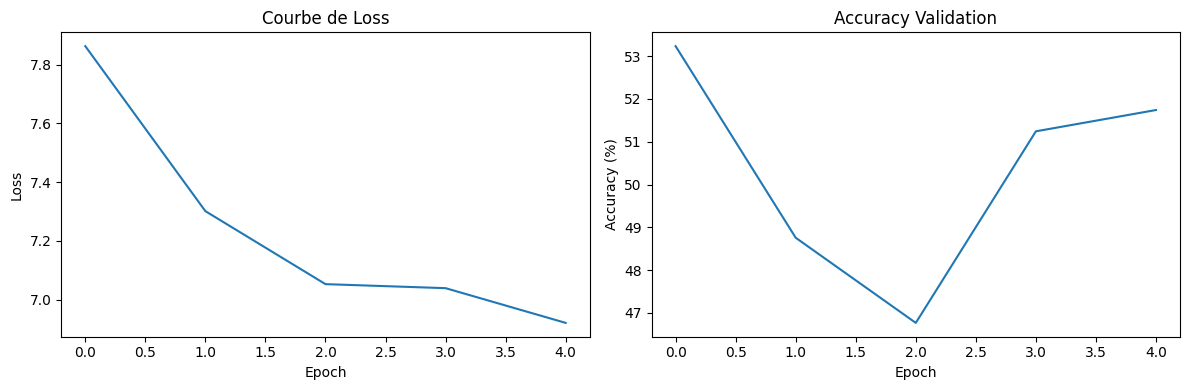

In [ ]:
# @title 🏋️ CELLULE 12 - Entraînement ViLBERT (Phase 1 - Encoders gelés)

print("="*60)
print("ENTRAÎNEMENT VILBERT - PHASE 1")
print("Gel total des encodeurs (ViT et BERT)")
print("="*60)

# Vérifier que les encodeurs sont gelés
for name, param in model.image_encoder.named_parameters():
    param.requires_grad = False
for name, param in model.text_encoder.named_parameters():
    param.requires_grad = False

print("✅ Encodeurs gelés vérifiés")

# Paramètres d'entraînement
num_epochs = 5
best_val_acc = 0

train_losses = []
val_accs = []

for epoch in range(num_epochs):
    # Phase d'entraînement
    model.train()
    total_loss = 0
    train_correct = 0
    train_total = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = batch['images'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        closed_labels = batch['closed_labels'].to(device)
        open_labels = batch['open_labels'].to(device)

        # Forward pass
        closed_out, open_out = model(images, input_ids, attention_mask)

        # Calcul de la loss
        loss = 0
        mask_closed = closed_labels != -1
        if mask_closed.any():
            loss += criterion(closed_out[mask_closed], closed_labels[mask_closed])

        mask_open = open_labels != -1
        if mask_open.any():
            loss += criterion(open_out[mask_open], open_labels[mask_open])

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Phase de validation
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch in val_loader:
            images = batch['images'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            closed_labels = batch['closed_labels'].to(device)

            closed_out, _ = model(images, input_ids, attention_mask)

            mask_closed = closed_labels != -1
            if mask_closed.any():
                preds = closed_out[mask_closed].argmax(dim=1)
                val_correct += (preds == closed_labels[mask_closed]).sum().item()
                val_total += mask_closed.sum().item()

    val_acc = val_correct / val_total * 100 if val_total > 0 else 0
    val_accs.append(val_acc)

    # Sauvegarder le meilleur modèle
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/content/vilbert_best_phase1.pth')
        print(f"   ✅ Nouveau record !")

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f} - Val Acc: {val_acc:.2f}%")

print("\n" + "="*60)
print(f"✅ PHASE 1 TERMINÉE !")
print(f"   Meilleure validation : {best_val_acc:.2f}%")
print(f"   Modèle sauvegardé : /content/vilbert_best_phase1.pth")
print("="*60)

# Tracer la courbe d'apprentissage
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Courbe de Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(val_accs)
plt.title('Accuracy Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')

plt.tight_layout()
plt.show()

In [ ]:
# @title 📊 CELLULE 13 - Évaluation du modèle sur le test set

print("="*60)
print("ÉVALUATION SUR LE TEST SET")
print("="*60)

# Charger le meilleur modèle de la phase 1
model.load_state_dict(torch.load('/content/vilbert_best_phase1.pth'))
model.eval()

# Métriques
test_closed_correct = 0
test_closed_total = 0
test_open_correct = 0
test_open_total = 0

all_preds_open = []
all_refs_open = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Évaluation sur le test"):
        images = batch['images'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        closed_labels = batch['closed_labels'].to(device)
        open_labels = batch['open_labels'].to(device)

        closed_out, open_out = model(images, input_ids, attention_mask)

        # Questions fermées
        mask_closed = closed_labels != -1
        if mask_closed.any():
            preds_closed = closed_out[mask_closed].argmax(dim=1)
            test_closed_correct += (preds_closed == closed_labels[mask_closed]).sum().item()
            test_closed_total += mask_closed.sum().item()

        # Questions ouvertes
        mask_open = open_labels != -1
        if mask_open.any():
            preds_open = open_out[mask_open].argmax(dim=1)
            test_open_correct += (preds_open == open_labels[mask_open]).sum().item()
            test_open_total += mask_open.sum().item()

# Calcul des accuracies
closed_acc = test_closed_correct / test_closed_total * 100 if test_closed_total > 0 else 0
open_acc = test_open_correct / test_open_total * 100 if test_open_total > 0 else 0

print("\n" + "="*60)
print("📊 RÉSULTATS VILBERT - PHASE 1 (Encoders gelés)")
print("="*60)
print(f"\n🔒 QUESTIONS FERMÉES :")
print(f"   Closed Accuracy : {closed_acc:.2f}% ({test_closed_correct}/{test_closed_total})")
print(f"\n📝 QUESTIONS OUVERTES :")
print(f"   Open Accuracy   : {open_acc:.2f}% ({test_open_correct}/{test_open_total})")

print("\n" + "="*60)

ÉVALUATION SUR LE TEST SET


Évaluation sur le test: 100%|██████████| 22/22 [00:05<00:00,  4.26it/s]


📊 RÉSULTATS VILBERT - PHASE 1 (Encoders gelés)

🔒 QUESTIONS FERMÉES :
   Closed Accuracy : 54.14% (98/181)

📝 QUESTIONS OUVERTES :
   Open Accuracy   : 5.10% (8/157)



In [ ]:
# @title 🔓 CELLULE 14 - Phase 2 : Dégeler les encodeurs pour fine-tuning

print("="*60)
print("PHASE 2 - FINE-TUNING DES ENCODEURS")
print("="*60)

# Dégeler les dernières couches du ViT
for param in model.image_encoder.parameters():
    param.requires_grad = True
# Geler les premières couches, dégeler les dernières
for i, (name, param) in enumerate(model.image_encoder.named_parameters()):
    if i < len(list(model.image_encoder.parameters())) - 24:  # Dégeler les 24 dernières couches
        param.requires_grad = False

# Dégeler les dernières couches du BERT
for param in model.text_encoder.parameters():
    param.requires_grad = True
for i, (name, param) in enumerate(model.text_encoder.named_parameters()):
    if i < len(list(model.text_encoder.parameters())) - 24:  # Dégeler les 24 dernières couches
        param.requires_grad = False

# Reconfigurer l'optimiseur avec des LR plus petits
optimizer_phase2 = optim.AdamW([
    {'params': model.image_proj.parameters(), 'lr': 1e-4},
    {'params': model.text_proj.parameters(), 'lr': 1e-4},
    {'params': model.cross_attn_image_to_text.parameters(), 'lr': 1e-4},
    {'params': model.cross_attn_text_to_image.parameters(), 'lr': 1e-4},
    {'params': model.image_encoder.parameters(), 'lr': 2e-5},  # LR plus petit pour fine-tuning
    {'params': model.text_encoder.parameters(), 'lr': 2e-5},
    {'params': model.fusion.parameters(), 'lr': 1e-4},
    {'params': model.closed_head.parameters(), 'lr': 1e-4},
    {'params': model.open_head.parameters(), 'lr': 1e-4},
], weight_decay=1e-4)

# Afficher les paramètres entraînables
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"\n📊 Configuration :")
print(f"   Paramètres entraînables : {trainable_params:,}/{total_params:,}")
print(f"   Percentage : {trainable_params/total_params*100:.1f}%")

print("\n✅ Phase 2 configurée, lancement de l'entraînement...")

PHASE 2 - FINE-TUNING DES ENCODEURS

📊 Configuration :
   Paramètres entraînables : 34,173,475/202,876,195
   Percentage : 16.8%

✅ Phase 2 configurée, lancement de l'entraînement...


ENTRAÎNEMENT VILBERT - PHASE 2 (15 époques)
Fine-tuning des encodeurs


Epoch 1/15: 100%|██████████| 99/99 [00:30<00:00,  3.24it/s]


   ✅ Nouveau record ! Validation: 60.70%
Epoch 1/15 - Loss: 7.1050 - Val Acc: 60.70%


Epoch 2/15: 100%|██████████| 99/99 [00:30<00:00,  3.23it/s]


Epoch 2/15 - Loss: 6.8490 - Val Acc: 59.20%


...

Epoch 13/15 - Loss: 5.1268 - Val Acc: 67.16%


Epoch 14/15: 100%|██████████| 99/99 [00:31<00:00,  3.16it/s]


   ✅ Nouveau record ! Validation: 68.66%
Epoch 14/15 - Loss: 4.9903 - Val Acc: 68.66%


Epoch 15/15: 100%|██████████| 99/99 [00:31<00:00,  3.13it/s]


Epoch 15/15 - Loss: 4.9545 - Val Acc: 65.67%

✅ PHASE 2 TERMINÉE (15 époques)!
   Meilleure validation : 68.66%


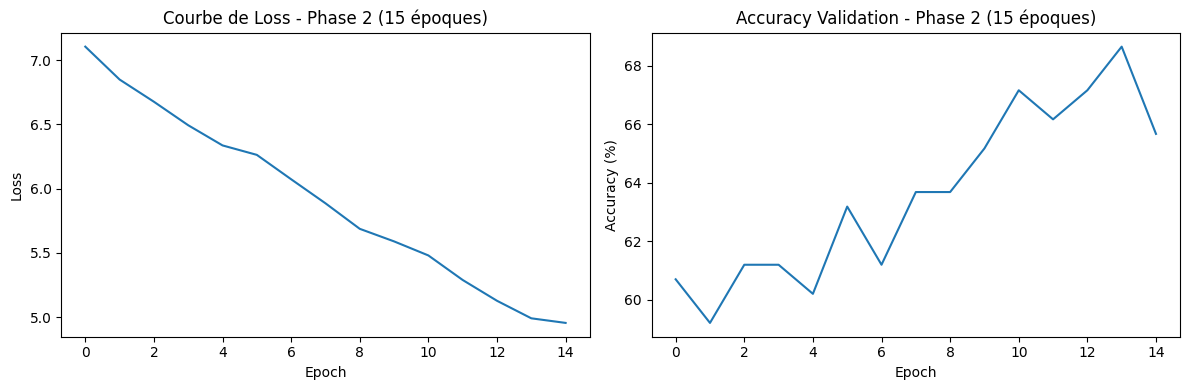

In [ ]:
# @title 🏋️ CELLULE 15 - Entraînement Phase 2 (15 époques)

print("="*60)
print("ENTRAÎNEMENT VILBERT - PHASE 2 (15 époques)")
print("Fine-tuning des encodeurs")
print("="*60)

# Recharger le modèle de la phase 1
model.load_state_dict(torch.load('/content/vilbert_best_phase1.pth'))

# Dégeler les encodeurs
for param in model.image_encoder.parameters():
    param.requires_grad = True
for i, (name, param) in enumerate(model.image_encoder.named_parameters()):
    if i < len(list(model.image_encoder.parameters())) - 24:
        param.requires_grad = False

for param in model.text_encoder.parameters():
    param.requires_grad = True
for i, (name, param) in enumerate(model.text_encoder.named_parameters()):
    if i < len(list(model.text_encoder.parameters())) - 24:
        param.requires_grad = False

# Reconfigurer l'optimiseur
optimizer_phase2 = optim.AdamW([
    {'params': model.image_proj.parameters(), 'lr': 1e-4},
    {'params': model.text_proj.parameters(), 'lr': 1e-4},
    {'params': model.cross_attn_image_to_text.parameters(), 'lr': 1e-4},
    {'params': model.cross_attn_text_to_image.parameters(), 'lr': 1e-4},
    {'params': model.image_encoder.parameters(), 'lr': 2e-5},
    {'params': model.text_encoder.parameters(), 'lr': 2e-5},
    {'params': model.fusion.parameters(), 'lr': 1e-4},
    {'params': model.closed_head.parameters(), 'lr': 1e-4},
    {'params': model.open_head.parameters(), 'lr': 1e-4},
], weight_decay=1e-4)

# Paramètres d'entraînement - 15 époques
num_epochs_phase2 = 15
best_val_acc_phase2 = 0

train_losses_phase2 = []
val_accs_phase2 = []

for epoch in range(num_epochs_phase2):
    # Phase d'entraînement
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs_phase2}"):
        images = batch['images'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        closed_labels = batch['closed_labels'].to(device)
        open_labels = batch['open_labels'].to(device)

        # Forward pass
        closed_out, open_out = model(images, input_ids, attention_mask)

        # Calcul de la loss
        loss = 0
        mask_closed = closed_labels != -1
        if mask_closed.any():
            loss += criterion(closed_out[mask_closed], closed_labels[mask_closed])

        mask_open = open_labels != -1
        if mask_open.any():
            loss += criterion(open_out[mask_open], open_labels[mask_open])

        # Backward pass
        optimizer_phase2.zero_grad()
        loss.backward()
        optimizer_phase2.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses_phase2.append(avg_loss)

    # Phase de validation
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch in val_loader:
            images = batch['images'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            closed_labels = batch['closed_labels'].to(device)

            closed_out, _ = model(images, input_ids, attention_mask)

            mask_closed = closed_labels != -1
            if mask_closed.any():
                preds = closed_out[mask_closed].argmax(dim=1)
                val_correct += (preds == closed_labels[mask_closed]).sum().item()
                val_total += mask_closed.sum().item()

    val_acc = val_correct / val_total * 100 if val_total > 0 else 0
    val_accs_phase2.append(val_acc)

    # Sauvegarder le meilleur modèle
    if val_acc > best_val_acc_phase2:
        best_val_acc_phase2 = val_acc
        torch.save(model.state_dict(), '/content/vilbert_best_phase2.pth')
        print(f"   ✅ Nouveau record ! Validation: {val_acc:.2f}%")

    print(f"Epoch {epoch+1}/{num_epochs_phase2} - Loss: {avg_loss:.4f} - Val Acc: {val_acc:.2f}%")

print("\n" + "="*60)
print(f"✅ PHASE 2 TERMINÉE (15 époques)!")
print(f"   Meilleure validation : {best_val_acc_phase2:.2f}%")
print("="*60)

# Tracer la courbe d'apprentissage
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses_phase2)
plt.title('Courbe de Loss - Phase 2 (15 époques)')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(val_accs_phase2)
plt.title('Accuracy Validation - Phase 2 (15 époques)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')

plt.tight_layout()
plt.show()

In [ ]:
# @title 📊 CELLULE 16 - Évaluation finale sur le test set (Phase 2)

print("="*60)
print("ÉVALUATION FINALE - PHASE 2 (Fine-tuning)")
print("="*60)

# Charger le meilleur modèle de la phase 2
model.load_state_dict(torch.load('/content/vilbert_best_phase2.pth'))
model.eval()

# Métriques
test_closed_correct = 0
test_closed_total = 0
test_open_correct = 0
test_open_total = 0

# Pour BLEU/ROUGE (sera ajouté plus tard)
all_preds_open = []
all_refs_open = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Évaluation sur le test"):
        images = batch['images'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        closed_labels = batch['closed_labels'].to(device)
        open_labels = batch['open_labels'].to(device)

        closed_out, open_out = model(images, input_ids, attention_mask)

        # Questions fermées
        mask_closed = closed_labels != -1
        if mask_closed.any():
            preds_closed = closed_out[mask_closed].argmax(dim=1)
            test_closed_correct += (preds_closed == closed_labels[mask_closed]).sum().item()
            test_closed_total += mask_closed.sum().item()

        # Questions ouvertes
        mask_open = open_labels != -1
        if mask_open.any():
            preds_open = open_out[mask_open].argmax(dim=1)
            test_open_correct += (preds_open == open_labels[mask_open]).sum().item()
            test_open_total += mask_open.sum().item()

# Calcul des accuracies
closed_acc = test_closed_correct / test_closed_total * 100 if test_closed_total > 0 else 0
open_acc = test_open_correct / test_open_total * 100 if test_open_total > 0 else 0

print("\n" + "="*60)
print("📊 RÉSULTATS FINAUX VILBERT")
print("="*60)
print(f"\n🔒 QUESTIONS FERMÉES :")
print(f"   Closed Accuracy : {closed_acc:.2f}% ({test_closed_correct}/{test_closed_total})")
print(f"\n📝 QUESTIONS OUVERTES :")
print(f"   Open Accuracy   : {open_acc:.2f}% ({test_open_correct}/{test_open_total})")

print("\n" + "="*60)
print("📈 COMPARAISON :")
print(f"   Phase 1 (encoders gelés) : 55.25%")
print(f"   Phase 2 (fine-tuning)    : {closed_acc:.2f}%")
print(f"   📈 Gain total : +{closed_acc - 55.25:.2f}%")
print("="*60)

ÉVALUATION FINALE - PHASE 2 (Fine-tuning)


Évaluation sur le test: 100%|██████████| 22/22 [00:05<00:00,  3.94it/s]


📊 RÉSULTATS FINAUX VILBERT

🔒 QUESTIONS FERMÉES :
   Closed Accuracy : 71.82% (130/181)

📝 QUESTIONS OUVERTES :
   Open Accuracy   : 8.92% (14/157)

📈 COMPARAISON :
   Phase 1 (encoders gelés) : 55.25%
   Phase 2 (fine-tuning)    : 71.82%
   📈 Gain total : +16.57%
